# Predicting Popularity on Spotify

This example uses the <a href="https://www.kaggle.com/yamaerenay/spotify-dataset-19212020-160k-tracks">publicly-available Spotify from Kaggle</a> to predict the popularity of Polish songs and artists on Spotify. We'll also use a model to group artists together based on how similar their songs are.<br><br>You can download the Jupyter notebook of this study <a href="spotify.ipynb">here</a>.

The "tracks" dataset (tracks.csv) have the following features: 
<ul class="ul_content">
    <li>id represents the Id of the track generated by Spotify</li>
</ul>

Numerical:
<ul class="ul_content">
    <li>acousticness (range: [0,1]) </li>
    <li>danceability (range: [0,1]) </li>
    <li>energy, (range: [0,1]) </li>
    <li>duration_ms (range: [200000,300000]) </li>
    <li>instrumentalness (range: [0,1]) </li>
    <li>valence (range: [0,1]) </li>
    <li>popularity (range: [0,100]) </li>
    <li>tempo (range: [50,150]) </li>
    <li>liveness (range: [0,1]) </li>
    <li>loudness (range: [-60,0]) </li>
    <li>speechiness (range: [0,1]) </li>
</ul>

Dummy:
<ul class="ul_content">
    <li>mode (0 = Minor, 1 = Major)</li>
    <li>explicit (0 = No explicit content and 1 = Explicit content)</li>
</ul>

Categorical:
<ul class="ul_content">
    <li>key - keys on an octave encoded as integers in range [0,11] (C = 0, C# = 1, etc.)</li>
    <li>timesignature - predicted time signature</li>
    <li>artists - list of contributing artists</li>
    <li>artists - list of IDs of contributing artists</li>
    <li>release_date - date of release (yyyy-mm-dd)</li>
    <li>name - track name</li>
</ul>

The "artists" dataset (artists.csv) has the following features:
<ul class="ul_content">
    <li>id - ID of the artist</li>
    <li>name - artist name</li>
    <li>followers - how many followers the artist has</li>
    <li>popularity - popularity of the artists based on their tracks</li>
    <li>genres - list of genres covered by the artist's tracks</li>
</ul>

### Import libraries

Start by importing VerticaPy and loading the SQL extension, which allows you to query the Vertica database with SQL.

In [1]:
import verticapy as vp
%load_ext verticapy.sql

This example uses the following version of VerticaPy:

In [2]:
vp.__version__

'0.9.0'

Connect to Vertica. This example uses an existing connection called "VerticaDSN." For details on how to create a connection, use see the <a href="../../connection.php">connection tutorial</a>.

In [3]:
vp.connect("VerticaDSN")

Create a new schema, "spotify."

In [4]:
vp.drop("spotify", method = "schema")
vp.create_schema("spotify")

True

### Data Loading

Load the datasets into the vDataFrame with read_csv() and then view them with display().

In [5]:
# load datasets as vDataFrame objects
artists = vp.read_csv("data/artists.csv", schema = "spotify", parse_nrows = 100)
tracks  = vp.read_csv("data/tracks.csv" , schema = "spotify", parse_nrows = 100)

The table "spotify"."artists" has been successfully created.
The table "spotify"."tracks" has been successfully created.


,AbcidVarchar(44),"123followersNumeric(7,2)",AbcVarchar(36),AbcnameVarchar(114),123popularityInt
1,0001K3ON4ACv7hte9Jlc6o,1.0,,Chris,0
2,0001ZVMPt41Vwzt1zsmuzp,13667.0,,Thyro & Yumi,39
3,0001cekkfdEBoMlwVQvpLg,80.0,,Jordan Colle,0
4,0001wHqxbF2YYRQxGdbyER,6329.0,,Motion Drive,19
5,0002XY9y3JhjzTZqNCqEcv,1828.0,,Katie Price & Peter Andre,0
6,00045gNg7mLEf9UY9yhD0t,829.0,,Kubus & BangBang,13
7,0004m70bDmySiyX0mbJMNS,0.0,,Carla Sanders,0
8,0004mMWDlIBRhLMZP3p92i,4.0,,Yung Danzy,0
9,00052qkj8osxzuMhyZA88Y,1.0,,Stephen Olaussen,0
10,00062105bTKjdbdc1K1UpI,0.0,,懾魂紫,0

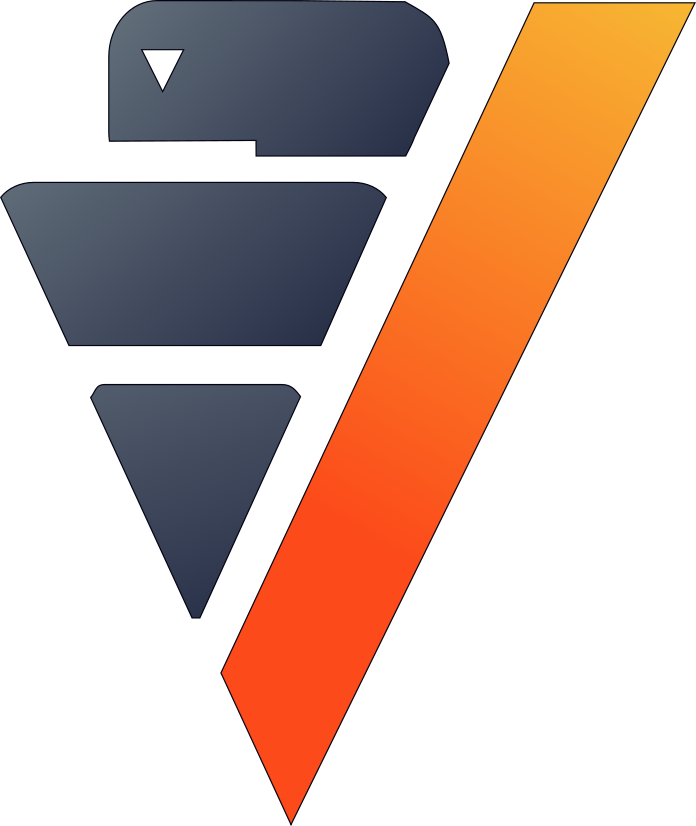

,AbcidVarchar(44),AbcVarchar(96),123popularityInt,123duration_msInt,123explicitInt,AbcVarchar(100),AbcVarchar(156),Abcrelease_dateVarchar(20),"123danceabilityNumeric(6,4)","123energyNumeric(8,6)",123keyInt,"123loudnessNumeric(8,4)",123modeInt,"123speechinessNumeric(7,5)","123acousticnessNumeric(6,4)",123instrumentalnessFloat,"123livenessNumeric(7,5)","123valenceNumeric(7,5)","123tempoNumeric(9,4)",123time_signatureInt
1,0004Uy71ku11n3LMpuyf59,,34,258907,0,,,2012-01-01,0.623,0.599,6,-9.255,1,0.0255,0.177,0.00148,0.0748,0.381,140.056,4
2,000CSYu4rvd8cQ7JilfxhZ,,43,189107,0,,,2005-05-03,0.624,0.766,2,-7.86,1,0.0731,0.345,0.0,0.113,0.548,95.128,4
3,000DsoWJKHdaUmhgcnpr8j,,16,234533,0,,,1977-07-11,0.572,0.608,7,-10.224,1,0.555,0.642,0.00022,0.344,0.559,106.453,4
4,000G1xMMuwxNHmwVsBdtj1,,32,182347,0,,,1978-09-23,0.256,0.895,2,-4.86,1,0.0707,0.0131,0.000106,0.0821,0.555,191.307,4
5,000KblXP5csWFFFsD6smOy,,35,240013,0,,,2006-07-08,0.619,0.518,4,-5.392,0,0.0534,0.805,0.0,0.102,0.314,143.757,3
6,000Npgk5e2SgwGaIsN3ztv,,0,206972,0,,,1953-12-31,0.277,0.145,3,-19.898,1,0.0845,0.98,0.879,0.111,0.494,75.644,4
7,000P83HDtOHcNVFZy7Q2Yu,,18,242493,0,,,1980,0.619,0.561,7,-8.377,0,0.0736,0.438,4.17e-05,0.126,0.696,88.94,4
8,000RDCYioLteXcutOjeweY,,54,190203,0,,,2018-02-12,0.679,0.77,0,-3.537,1,0.19,0.0583,0.0,0.0825,0.839,161.721,4
9,000TXa2oEZLYfQGPCiv23U,,6,243200,0,,,1982,0.61,0.91,6,-10.981,1,0.043,0.0606,0.0828,0.148,0.775,129.639,4
10,000TiSS4vK5su0MkoFyQbd,,44,159250,0,,,2017-12-22,0.72,0.646,6,-7.691,0,0.106,0.237,0.0,0.127,0.0958,80.013,4

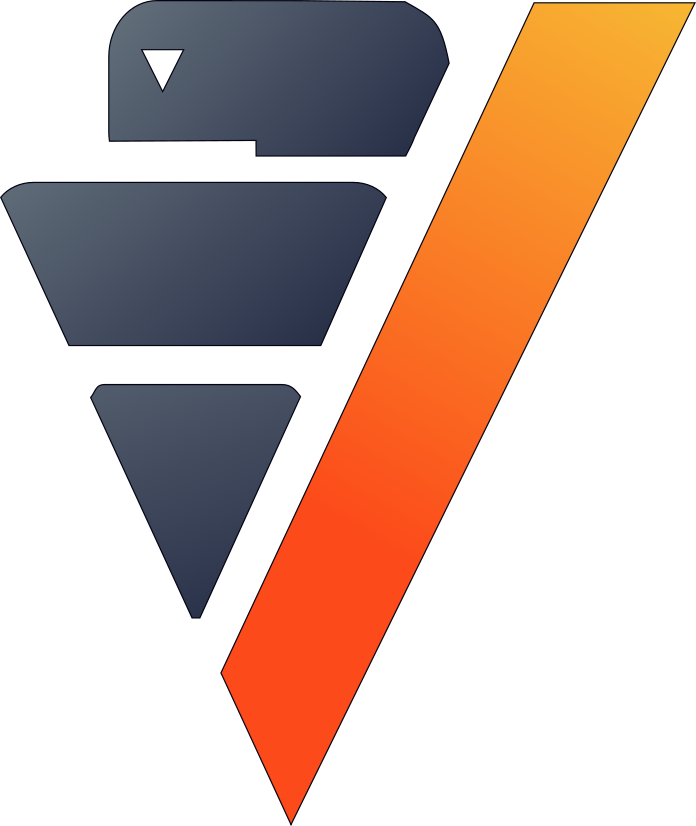

In [6]:
display(artists)
display(tracks)

## Data Exploration

The "artists" dataset is too broad for us to use right now; we're only concerned with Polish artists, so let's extract and save them to our Vertica database.

,AbcidVarchar(44),"123followersNumeric(7,2)",AbcVarchar(36),AbcVarchar(114),123popularityInteger
1,004reCzVFOidvBuYrYia9Y,12726.0,,,27
2,00drc18J6PkIXn24widBC5,3.0,,,0
3,00ekfPE5ZS3NwF8H8o8GBk,17574.0,,,47
4,0138Hlfmap3fEvKTqmZhE9,1289.0,,,5
5,018gIUaP08hROTOiVdiEQ3,584.0,,,8
6,01BlTZ696EkKe6xr56Gu6G,362.0,,,3
7,01TgMAgIALWvVXlKjUwpfn,1063.0,,,9
8,0244q9rIqAIzBFXKNNRN6O,27393.0,,,40
9,02Cq85QmaYHDi4dW7AxTRZ,749.0,,,9
10,02ESuuto8Jwyo4PeiJ1Xim,149.0,,,1

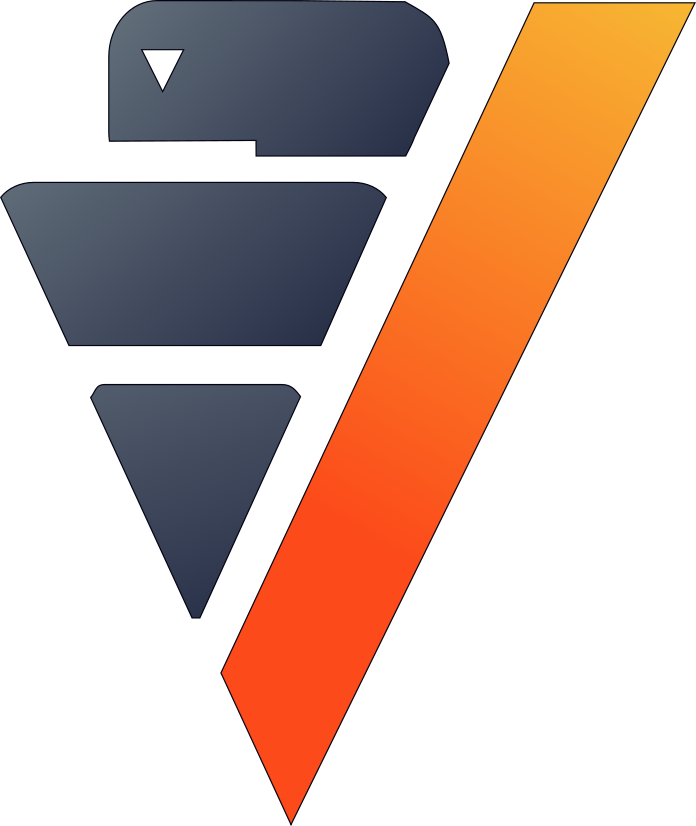

In [7]:
# filter polish artists out of the 'artists' dataset using information in 'genres' column
polish_artists = artists.search("genres ilike '%disco polo%' or genres ilike '%polish%'") 

# save it to the database
polish_artists.to_db('"spotify"."polish_artists"', relation_type = "table")

We can visualize the top 60 most-followed Polish artists with a bar chart.

In [8]:
# make a highchart of the top 60 most-followed Polish artists
polish_artists.hchart(x = "name",
                      y = "followers", 
                      aggregate = False,
                      kind = "bar",
                      max_cardinality = 60,
                      height = 900,
                      width = 1500)

We can do the same with the most popular tracks. For example, we can graph Monika Brodka's most popular tracks like so:

In [9]:
# find Monika Brodka's songs
brodka_tracks = tracks.search("artists ilike '%brodka%'")

# plot Brodka's tracks ordered by popularity
brodka_tracks.hchart(x = "name",
                     y = "popularity",
                     aggregate = False,
                     kind = "bar",
                     max_cardinality = 25) 

To get an idea of what makes Monika Brodka's songs popular, let's create a boxplot of the numerical feature distribution of her tracks.

In [10]:
## list of the relevant numerical features
numerical_features = ['danceability', 
                      'energy', 
                      'speechiness', 
                      'acousticness', 
                      'instrumentalness', 
                      'valence', 
                      'liveness'] 

# create a boxplot of the above features
brodka_tracks[numerical_features].hchart(kind = "boxplot")

Timing is a classic factor for success, so let's look at the popularity of Monika's songs over time with a smooth curve.

<AxesSubplot:xlabel='"release_date"', ylabel='"smoothed_popularity"'>

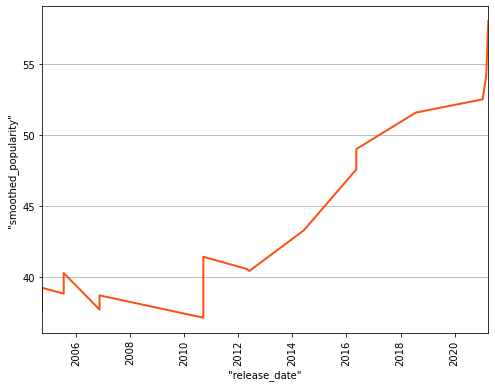

In [11]:
# extract year from the date
brodka_tracks['release_year'] = "year(release_date::date)"

# smooth the popularity using rolling mean
brodka_tracks.rolling(func = 'mean',
                      columns = 'popularity',
                      window = (-3, 3),
                      order_by = 'release_year',
                      name = 'smoothed_popularity')

# plot the smoothed curve for popularity of her songs
brodka_tracks.plot(ts = 'release_date', columns=['smoothed_popularity']) 

## Numerical-feature Analysis

Bringing it all together, let's try to get an idea of how these numerical features change and correlate with each other in Monika's most popular songs.

<AxesSubplot:xlabel='"release_year"'>

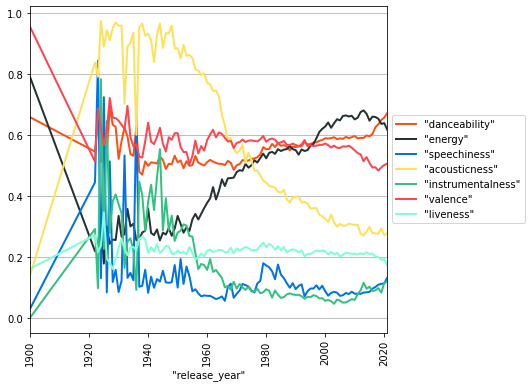

In [12]:
# extract year from date
tracks['release_year'] = "year(release_date::date)"

# get the average of numerical features during the year
yearly_aggs = tracks.groupby('release_year', ['AVG(danceability) as danceability',
                                              'AVG(energy) as energy', 
                                              'AVG(speechiness) AS speechiness', 
                                              'AVG(acousticness) AS acousticness', 
                                              'AVG(instrumentalness) AS instrumentalness',
                                              'AVG(valence) AS valence', 
                                              'AVG(liveness) AS liveness',])

# plot the cures for numerical features along the different years
yearly_aggs.plot(ts='release_year', 
                 columns=numerical_features)

,"""danceability""","""energy""","""speechiness""","""acousticness""","""instrumentalness""","""valence""","""liveness"""
"""danceability""",1.0,0.225378443312902,0.198422110210451,-0.228879028726738,-0.219560144635743,0.517690962189664,-0.107989997860069
"""energy""",0.225378443312902,1.0,-0.0588034003217321,-0.710939277579459,-0.190319675033783,0.360195098649349,0.12611905796149
"""speechiness""",0.198422110210451,-0.0588034003217321,1.0,0.0735189869046661,-0.101150709419063,0.0439632547745622,0.208192661333212
"""acousticness""",-0.228879028726738,-0.710939277579459,0.0735189869046661,1.0,0.199817518163958,-0.166786499501141,-0.00448565029093398
"""instrumentalness""",-0.219560144635743,-0.190319675033783,-0.101150709419063,0.199817518163958,1.0,-0.170613868369725,-0.0372257235123641
"""valence""",0.517690962189664,0.360195098649349,0.0439632547745622,-0.166786499501141,-0.170613868369725,1.0,-0.000143636296234245
"""liveness""",-0.107989997860069,0.12611905796149,0.208192661333212,-0.00448565029093398,-0.0372257235123641,-0.000143636296234245,1.0

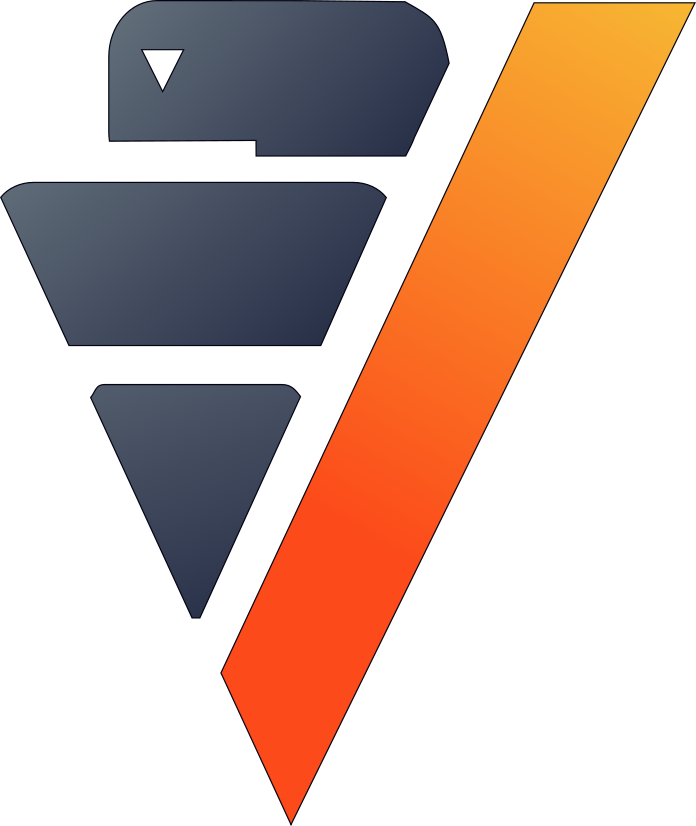

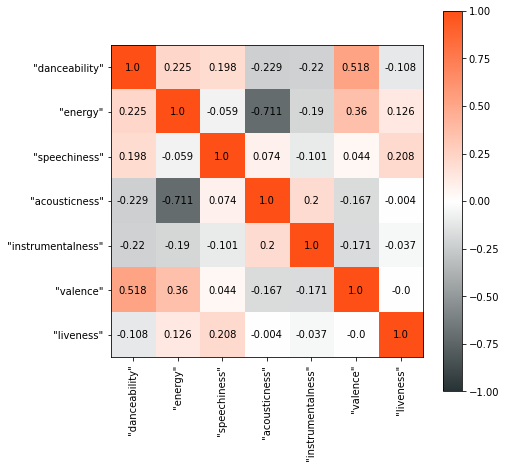

In [13]:
# correlation of numerical features
tracks[tracks[numerical_features]].corr()

# Feature Engineering

To expand our analysis, let's take into account some descriptive features. Since our goal is to predict popularity, some useful features might be:
<ul>
    <li>number of followers</li>
    <li>popularity for the artist of the track</li>
    <li>the number of artists per track</li>
</ul>

Additionally, we manipulate our data a bit to make things easier later on:
<ul>
    <li>converting the duration unit from 'ms' to 'minute'</li>
    <li>extracting the year from the date.</li>
</ul>

In [66]:
%%sql
CREATE TABLE spotify.polish_tracks AS
SELECT * FROM spotify.tracks 
WHERE id_artists IN (SELECT t.id_artists FROM spotify.tracks t JOIN spotify.polish_artists p
                     ON t.id_artists LIKE '%' || p.id || '%');
CREATE TABLE spotify.polish_tracks_clean AS
SELECT 
    x.*, 
    x.duration_ms / 60000 AS duration_minute,
    (CASE 
         WHEN LENGTH(x.release_date) = 4 THEN (release_date::INT) 
         ELSE YEAR(x.release_date::date) 
     END) AS release_year,
    y.followers AS artists_followers,
    y.popularity AS artist_popularity
FROM spotify.polish_tracks AS x LEFT JOIN spotify.artists AS y
ON x.id_artists LIKE '%' || y.id || '%';

CREATE
CREATE


,AbcidVarchar(44),AbcVarchar(96),123popularityInt,123duration_msInt,123explicitInt,AbcVarchar(100),AbcVarchar(156),Abcrelease_dateVarchar(20),"123danceabilityNumeric(6,4)","123energyNumeric(8,6)",123keyInt,"123loudnessNumeric(8,4)",123modeInt,"123speechinessNumeric(7,5)","123acousticnessNumeric(6,4)",123instrumentalnessFloat,"123livenessNumeric(7,5)","123valenceNumeric(7,5)","123tempoNumeric(9,4)",123time_signatureInt,"123duration_minuteNumeric(36,18)",123release_yearInt,"123artists_followersNumeric(7,2)",123artist_popularityInt,123nb_singersInteger
1,0004Uy71ku11n3LMpuyf59,,34,258907,0,,,2012-01-01,0.623,0.599,6,-9.255,1,0.0255,0.177,0.00148,0.0748,0.381,140.056,4,4.3151166666666665,2012,5425.0,36,1
2,008UO76dicJJrUb5g6WID0,,42,216813,0,,,2001,0.677,0.885,9,-4.108,0,0.0449,0.164,0.0,0.0827,0.741,119.981,4,3.61355,2001,47110.0,44,1
3,00D7fT49Q54HNiaaLY32UA,,41,196231,0,,,2017-06-07,0.541,0.672,1,-4.956,1,0.113,0.198,0.0,0.112,0.146,120.061,5,3.2705166666666665,2017,75395.0,59,3
4,00De7REGurYkmfrKAh6CU1,,36,400867,0,,,1992-10-30,0.218,0.104,11,-22.809,0,0.047,0.51,0.692,0.0688,0.0329,114.592,3,6.681116666666667,1992,11683.0,40,1
5,00KCwnrvIXX8GRU3ZMOIBW,,55,207821,0,,,2019-12-06,0.825,0.692,6,-6.084,0,0.0627,0.172,0.000996,0.0861,0.602,123.985,4,3.4636833333333334,2019,23399.0,54,1
6,00g7zzRDf2DOf4fKYzFTUA,,46,192857,0,,,2018-08-24,0.75,0.797,1,-6.516,1,0.332,0.567,0.0,0.0914,0.726,112.343,4,3.2142833333333334,2018,28135.0,43,1
7,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.573,0.674,7,-7.531,0,0.0947,0.629,0.0,0.217,0.928,98.842,4,1.6320666666666668,1978,5.0,4,2
8,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.573,0.674,7,-7.531,0,0.0947,0.629,0.0,0.217,0.928,98.842,4,1.6320666666666668,1978,5059.0,42,2
9,00l8ILQ8qgsew789dGn1Gh,,7,326240,0,,,1963-03-25,0.568,0.601,2,-7.875,0,0.0294,0.509,9.49e-06,0.156,0.78,102.428,4,5.437333333333333,1963,696.0,9,1
10,00vlVv7WLZjyRS783REKmn,,24,243107,0,,,1998,0.883,0.506,1,-8.137,1,0.372,0.0519,0.0,0.207,0.375,93.05,4,4.051783333333334,1998,41198.0,37,1

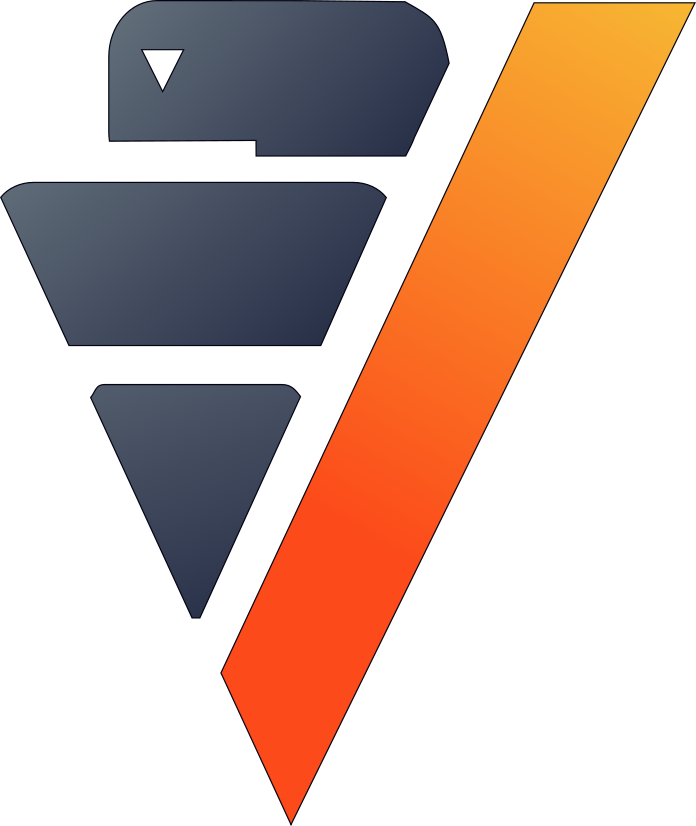

In [27]:
polish_tracks = vp.vDataFrame("spotify.polish_tracks_clean")

# count the number of artists per track
polish_tracks.regexp(column = "artists", 
                     pattern = ",", 
                     method = "count",
                     name = "nb_singers")
polish_tracks["nb_singers"].add(1)

Define a list of predictors and the response, and then save the normalized version of the final dataset to the database.

,AbcidVarchar(44),AbcVarchar(96),123popularityInt,123duration_msInt,123explicitInt,AbcVarchar(100),AbcVarchar(156),Abcrelease_dateVarchar(20),123danceabilityFloat,123energyFloat,123keyInt,123loudnessFloat,123modeInt,123speechinessFloat,123acousticnessFloat,123instrumentalnessFloat,123livenessFloat,123valenceFloat,"123tempoNumeric(9,4)",123time_signatureInt,123duration_minuteFloat,123release_yearFloat,123artists_followersFloat,123artist_popularityFloat,123nb_singersFloat
1,0004Uy71ku11n3LMpuyf59,,34,258907,0,,,2012-01-01,0.617324561403509,0.599361388077236,6,0.797675055385458,1,0.002405160161802,0.177889447236181,0.00151484135107472,0.061291989664083,0.365659943567771,140.056,4,0.16825584838614155,0.892857142857143,0.054260076228204,0.5,0.0
2,008UO76dicJJrUb5g6WID0,,42,216813,0,,,2001,0.676535087719298,0.886535931961723,9,0.925795932591542,0,0.023614299770417,0.164824120603015,0.0,0.069457364341085,0.74187480405476,119.981,4,0.13709357417826473,0.761904761904762,0.471264367816092,0.611111111111111,0.0
3,00D7fT49Q54HNiaaLY32UA,,41,196231,0,,,2017-06-07,0.527412280701754,0.672661184243556,1,0.904687227740024,1,0.098064939324369,0.198994974874372,0.0,0.099741602067183,0.120075242972097,120.061,5,0.12185667752442997,0.952380952380952,0.754219061052589,0.819444444444444,0.222222222222222
4,00De7REGurYkmfrKAh6CU1,,36,400867,0,,,1992-10-30,0.173245614035088,0.102328523661777,11,0.460284270529958,0,0.025910134470318,0.512562814070352,0.708290685772774,0.055090439276486,0.001881074302435,114.592,3,0.273349126443589,0.654761904761905,0.116863239398577,0.555555555555556,0.0
5,00KCwnrvIXX8GRU3ZMOIBW,,55,207821,0,,,2019-12-06,0.838815789473684,0.692743320179534,6,0.876608667513006,0,0.04307423198863,0.17286432160804,0.00101944728761515,0.07297157622739,0.596614066255617,123.985,4,0.13043677820550784,0.976190476190476,0.234066604643718,0.75,0.0
6,00g7zzRDf2DOf4fKYzFTUA,,46,192857,0,,,2018-08-24,0.756578947368421,0.79817453384342,1,0.865855176362233,1,0.337487700885536,0.569849246231156,0.0,0.078449612403101,0.726199184867802,112.343,4,0.11935889843055966,0.964285714285714,0.281444134329702,0.597222222222222,0.0
7,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.5625,0.674669397837154,7,0.840589450626042,0,0.078058379796655,0.632160804020101,0.0,0.208268733850129,0.937297523252168,98.842,4,0.049079804560260586,0.488095238095238,4.0014805478e-05,0.055555555555556,0.111111111111111
8,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.5625,0.674669397837154,7,0.840589450626042,0,0.078058379796655,0.632160804020101,0.0,0.208268733850129,0.937297523252168,98.842,4,0.049079804560260586,0.488095238095238,0.050598721526965,0.583333333333333,0.111111111111111
9,00l8ILQ8qgsew789dGn1Gh,,7,326240,0,,,1963-03-25,0.557017543859649,0.601369601670834,2,0.832026485450427,0,0.006668853175905,0.511557788944724,9.71340839303992e-06,0.145219638242894,0.782631413940851,102.428,4,0.2181026058631922,0.30952380952381,0.006952572451807,0.125,0.0
10,00vlVv7WLZjyRS783REKmn,,24,243107,0,,,1998,0.902412280701754,0.505979455974937,1,0.825504692206208,1,0.381217885645567,0.052160804020101,0.0,0.197932816537468,0.359389695892988,93.05,4,0.15655907610305003,0.726190476190476,0.412122485319568,0.513888888888889,0.0

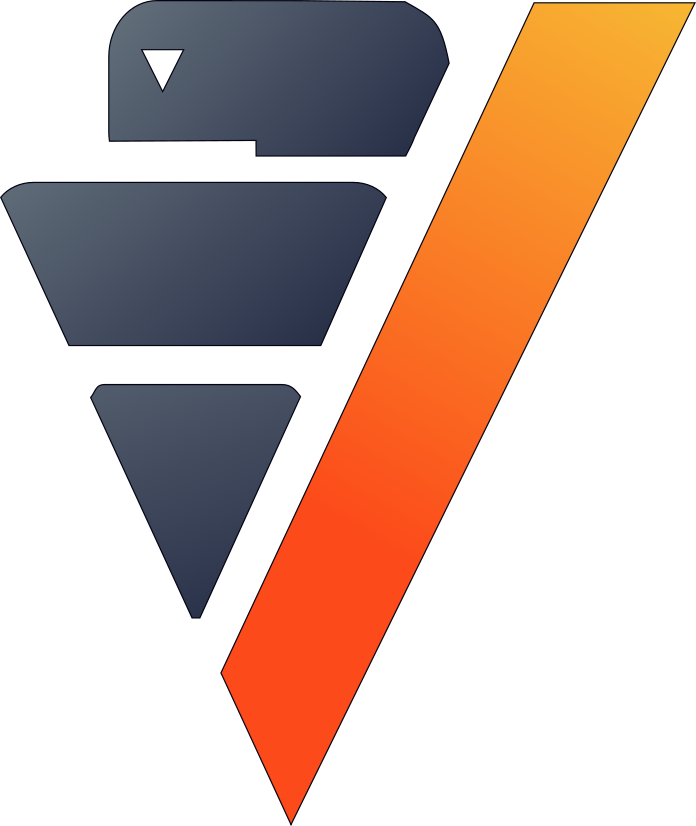

In [28]:
# define predictors and response
predictors = ['duration_minute', 
              'release_year', 
              'danceability', 
              'energy', 
              'loudness',
              'speechiness', 
              'acousticness', 
              'instrumentalness', 
              'liveness', 
              'valence', 
              'artists_followers', 
              'artist_popularity', 
              'nb_singers']
response = 'popularity'

# normalize the features
polish_tracks.normalize(method = "minmax",
                        columns = predictors)

# save the final dataset to the database
polish_tracks.to_db('"spotify"."polish_tracks_data_final"', relation_type = "table")

### Machine Learning

We can use AutoML to easily get a well-performing model.

In [29]:
# define a random seed so models tested by AutoML produce consistent results
vp.set_option("random_state", 2)

AutoML automatically tests several machine learning models and picks the best performing one.

In [30]:
from verticapy.learn.delphi import AutoML
# define the model
auto_model = AutoML('spotify.automl_spotify_polish',
                    estimator = "native",
                    preprocess_data = False,
                    stepwise = False,
                    cv = 2)

Train the model.

Starting AutoML




Testing Model - LinearRegression



Model: LinearRegression; Parameters: {'tol': 1e-06, 'max_iter': 100, 'solver': 'newton'}; Test_score: 8.066647640522543; Train_score: 8.118985304784605; Time: 0.20426690578460693;
Model: LinearRegression; Parameters: {'tol': 1e-06, 'max_iter': 100, 'solver': 'bfgs'}; Test_score: 8.06657408402635; Train_score: 8.118986556025963; Time: 0.7867480516433716;

Grid Search Selected Model
LinearRegression; Parameters: {'solver': 'bfgs', 'penalty': 'none', 'max_iter': 100, 'tol': 1e-06}; Test_score: 8.06657408402635; Train_score: 8.118986556025963; Time: 0.7867480516433716;

Testing Model - ElasticNet



Model: ElasticNet; Parameters: {'tol': 1e-06, 'max_iter': 100, 'solver': 'cgd', 'C': 1.0, 'l1_ratio': 0.5}; Test_score: 14.822426878049042; Train_score: 15.035727014744669; Time: 0.27442634105682373;

Grid Search Selected Model
ElasticNet; Parameters: {'solver': 'cgd', 'penalty': 'enet', 'max_iter': 100, 'l1_ratio': 0.5, 'C': 1.0, 'tol': 1e-06}; Test_score: 14.822426878049042; Train_score: 15.035727014744669; Time: 0.27442634105682373;

Testing Model - Ridge



Model: Ridge; Parameters: {'tol': 1e-06, 'max_iter': 100, 'C': 1.0}; Test_score: 8.064233984706952; Train_score: 8.121069572782197; Time: 0.20085954666137695;

Grid Search Selected Model
Ridge; Parameters: {'solver': 'newton', 'penalty': 'l2', 'max_iter': 100, 'C': 1.0, 'tol': 1e-06}; Test_score: 8.064233984706952; Train_score: 8.121069572782197; Time: 0.20085954666137695;

Testing Model - Lasso



Model: Lasso; Parameters: {'tol': 1e-06, 'max_iter': 100, 'solver': 'cgd', 'C': 1.0}; Test_score: 9.76754307664328; Train_score: 10.121086467655486; Time: 0.2544424533843994;

Grid Search Selected Model
Lasso; Parameters: {'solver': 'cgd', 'penalty': 'l1', 'max_iter': 100, 'C': 1.0, 'tol': 1e-06}; Test_score: 9.76754307664328; Train_score: 10.121086467655486; Time: 0.2544424533843994;

Testing Model - LinearSVR



Model: LinearSVR; Parameters: {'tol': 1e-06, 'fit_intercept': True, 'intercept_mode': 'regularized', 'max_iter': 100}; Test_score: 8.06441805263914; Train_score: 8.120720846232265; Time: 2.197774648666382;
Model: LinearSVR; Parameters: {'tol': 1e-06, 'fit_intercept': True, 'intercept_mode': 'unregularized', 'max_iter': 100}; Test_score: 8.065481552212296; Train_score: 8.119616043007014; Time: 2.323397994041443;
Model: LinearSVR; Parameters: {'tol': 1e-06, 'C': 1.0, 'fit_intercept': True, 'intercept_mode': 'regularized', 'max_iter': 100}; Test_score: 8.06441805263914; Train_score: 8.120720846232265; Time: 2.182707905769348;
Model: LinearSVR; Parameters: {'tol': 1e-06, 'C': 1.0, 'fit_intercept': True, 'intercept_mode': 'unregularized', 'max_iter': 100}; Test_score: 8.065481552212296; Train_score: 8.119616043007014; Time: 2.6499600410461426;

Grid Search Selected Model
LinearSVR; Parameters: {'tol': 1e-06, 'C': 1.0, 'max_iter': 100, 'fit_intercept': True, 'intercept_scaling': 1.0, 'interc

Model: RandomForestRegressor; Parameters: {'max_features': 'max', 'max_leaf_nodes': 128, 'max_depth': 5, 'min_samples_leaf': 1, 'min_info_gain': 0.0, 'nbins': 32}; Test_score: 7.113663323363556; Train_score: 6.39265180458105; Time: 0.42195308208465576;
Model: RandomForestRegressor; Parameters: {'max_features': 'max', 'max_leaf_nodes': 1000, 'max_depth': 5, 'min_samples_leaf': 1, 'min_info_gain': 0.0, 'nbins': 32}; Test_score: 7.113663323363556; Train_score: 6.39265180458105; Time: 0.3885120153427124;
Model: RandomForestRegressor; Parameters: {'max_features': 'max', 'max_leaf_nodes': 128, 'max_depth': 5, 'min_samples_leaf': 2, 'min_info_gain': 0.0, 'nbins': 32}; Test_score: 7.181553675673483; Train_score: 6.5483753528126805; Time: 0.40996646881103516;
Model: RandomForestRegressor; Parameters: {'max_features': 'max', 'max_leaf_nodes': 64, 'max_depth': 4, 'min_samples_leaf': 1, 'min_info_gain': 0.0, 'nbins': 32}; Test_score: 7.266855044387853; Train_score: 6.809449561850816; Time: 0.39678

,model_type,,avg_score,avg_train_score,avg_time,score_std,score_train_std,
1,RandomForestRegressor,,7.064327407880318,6.210967309985071,0.4239314794540405,0.021951610316419245,0.05495843581963396,""" readonly>"
2,RandomForestRegressor,,7.113663323363556,6.39265180458105,0.42195308208465576,0.04420745773425167,0.05405953173125159,""" readonly>"
3,RandomForestRegressor,,7.113663323363556,6.39265180458105,0.3885120153427124,0.04420745773425167,0.05405953173125159,""" readonly>"
4,RandomForestRegressor,,7.181553675673483,6.5483753528126805,0.40996646881103516,0.0457345096188477,0.05011685394254436,""" readonly>"
5,RandomForestRegressor,,7.266855044387853,6.809449561850816,0.3967854976654053,0.05954893368677364,0.20818778505776214,""" readonly>"
6,Ridge,,8.064233984706952,8.121069572782197,0.20085954666137695,0.15216905564050348,0.1513846089750132,""" readonly>"
7,LinearSVR,,8.06441805263914,8.120720846232265,2.197774648666382,0.15018542501699342,0.1512890154897334,""" readonly>"
8,LinearSVR,,8.06441805263914,8.120720846232265,2.182707905769348,0.15018542501699342,0.1512890154897334,""" readonly>"
9,LinearSVR,,8.065481552212296,8.119616043007014,2.323397994041443,0.14813750528375574,0.15105738388572493,""" readonly>"
10,LinearSVR,,8.065481552212296,8.119616043007014,2.6499600410461426,0.14813750528375574,0.15105738388572493,""" readonly>"

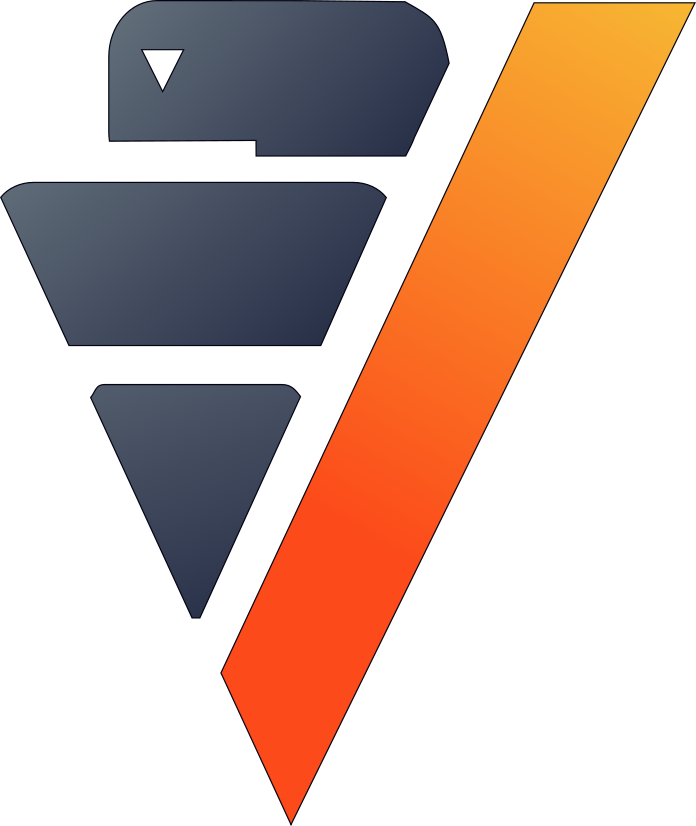

In [31]:
%%time
auto_model.fit('spotify.polish_tracks_data_final', 
               predictors, 
               response) 

The numbers are hard to grasp on their own, so let's plot the performance and efficiency of each model.

<AxesSubplot:xlabel='time', ylabel='score'>

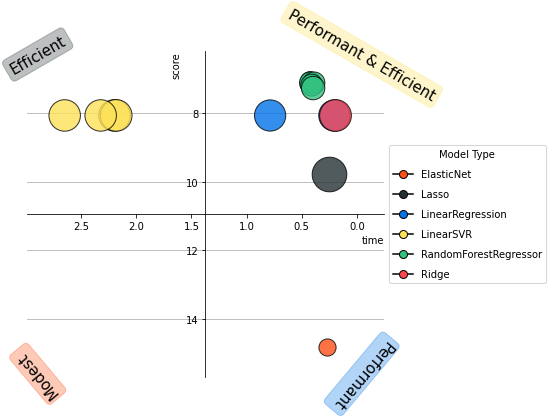

In [32]:
# visualize the performance of different models
auto_model.plot()

Extract the best model according to AutoML. From here, we can look at the model type and its hyperparameters.

In [33]:
# extract the model type and hyperparameters
best_model = auto_model.best_model_
bm_type = best_model.type
hyperparams = best_model.get_params()

print(bm_type)
print(hyperparams)

RandomForestRegressor
{'n_estimators': 10, 'max_features': 'max', 'max_leaf_nodes': 64, 'sample': 0.632, 'max_depth': 6, 'min_samples_leaf': 2, 'min_info_gain': 0.0, 'nbins': 32}


Thanks to AutoML, we know best model type and its hyperparameters. Let's create a new model with this information in mind.

,AbcidVarchar(44),AbcVarchar(96),123popularityInt,123duration_msInt,123explicitInt,AbcVarchar(100),AbcVarchar(156),Abcrelease_dateVarchar(20),123danceabilityFloat,123energyFloat,123keyInt,123loudnessFloat,123modeInt,123speechinessFloat,123acousticnessFloat,123instrumentalnessFloat,123livenessFloat,123valenceFloat,"123tempoNumeric(9,4)",123time_signatureInt,123duration_minuteFloat,123release_yearFloat,123artists_followersFloat,123artist_popularityFloat,123nb_singersFloat,123estimated_popularityFloat
1,0004Uy71ku11n3LMpuyf59,,34,258907,0,,,2012-01-01,0.617324561403509,0.599361388077236,6,0.797675055385458,1,0.002405160161802,0.177889447236181,0.00151484135107472,0.061291989664083,0.365659943567771,140.056,4,0.16825584838614155,0.892857142857143,0.054260076228204,0.5,0.0,40.4301647912923
2,008UO76dicJJrUb5g6WID0,,42,216813,0,,,2001,0.676535087719298,0.886535931961723,9,0.925795932591542,0,0.023614299770417,0.164824120603015,0.0,0.069457364341085,0.74187480405476,119.981,4,0.13709357417826473,0.761904761904762,0.471264367816092,0.611111111111111,0.0,34.869262824777
3,00D7fT49Q54HNiaaLY32UA,,41,196231,0,,,2017-06-07,0.527412280701754,0.672661184243556,1,0.904687227740024,1,0.098064939324369,0.198994974874372,0.0,0.099741602067183,0.120075242972097,120.061,5,0.12185667752442997,0.952380952380952,0.754219061052589,0.819444444444444,0.222222222222222,45.0804559629553
4,00De7REGurYkmfrKAh6CU1,,36,400867,0,,,1992-10-30,0.173245614035088,0.102328523661777,11,0.460284270529958,0,0.025910134470318,0.512562814070352,0.708290685772774,0.055090439276486,0.001881074302435,114.592,3,0.273349126443589,0.654761904761905,0.116863239398577,0.555555555555556,0.0,30.6638002980626
5,00KCwnrvIXX8GRU3ZMOIBW,,55,207821,0,,,2019-12-06,0.838815789473684,0.692743320179534,6,0.876608667513006,0,0.04307423198863,0.17286432160804,0.00101944728761515,0.07297157622739,0.596614066255617,123.985,4,0.13043677820550784,0.976190476190476,0.234066604643718,0.75,0.0,52.0762280321545
6,00g7zzRDf2DOf4fKYzFTUA,,46,192857,0,,,2018-08-24,0.756578947368421,0.79817453384342,1,0.865855176362233,1,0.337487700885536,0.569849246231156,0.0,0.078449612403101,0.726199184867802,112.343,4,0.11935889843055966,0.964285714285714,0.281444134329702,0.597222222222222,0.0,45.0804559629553
7,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.5625,0.674669397837154,7,0.840589450626042,0,0.078058379796655,0.632160804020101,0.0,0.208268733850129,0.937297523252168,98.842,4,0.049079804560260586,0.488095238095238,4.0014805478e-05,0.055555555555556,0.111111111111111,2.86773809523809
8,00i4Q7OfN0mGnUyuyQcAdZ,,2,97924,0,,,1978-01-01,0.5625,0.674669397837154,7,0.840589450626042,0,0.078058379796655,0.632160804020101,0.0,0.208268733850129,0.937297523252168,98.842,4,0.049079804560260586,0.488095238095238,0.050598721526965,0.583333333333333,0.111111111111111,10.6410158019808
9,00l8ILQ8qgsew789dGn1Gh,,7,326240,0,,,1963-03-25,0.557017543859649,0.601369601670834,2,0.832026485450427,0,0.006668853175905,0.511557788944724,9.71340839303992e-06,0.145219638242894,0.782631413940851,102.428,4,0.2181026058631922,0.30952380952381,0.006952572451807,0.125,0.0,7.30127856572452
10,00vlVv7WLZjyRS783REKmn,,24,243107,0,,,1998,0.902412280701754,0.505979455974937,1,0.825504692206208,1,0.381217885645567,0.052160804020101,0.0,0.197932816537468,0.359389695892988,93.05,4,0.15655907610305003,0.726190476190476,0.412122485319568,0.513888888888889,0.0,24.9533724588221

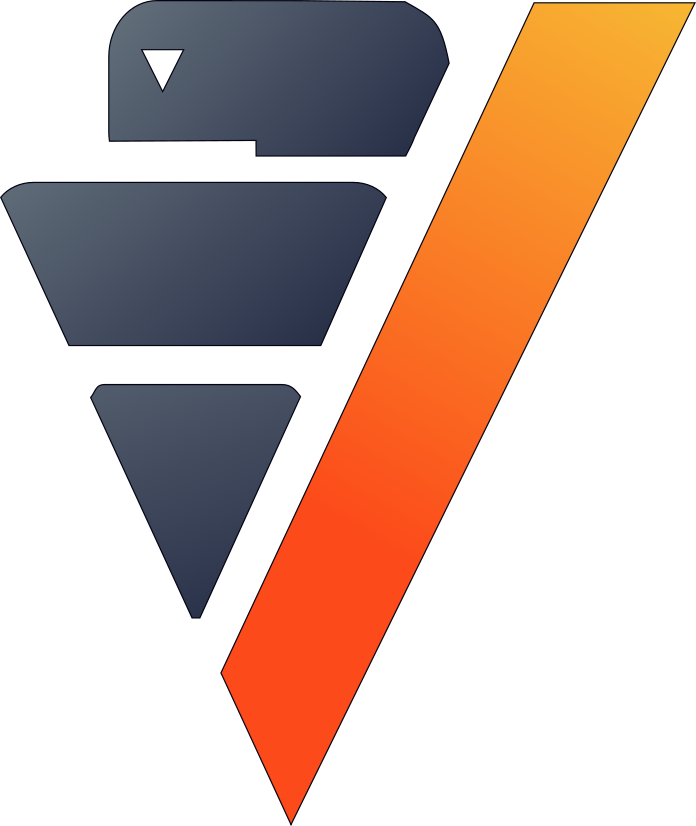

In [47]:
from verticapy.learn.ensemble import RandomForestRegressor

# define the model
rf_model = RandomForestRegressor('spotify.randomforest_spotify', **hyperparams)

# train the model
rf_model.fit(polish_tracks, predictors, response) 

# use the model to predict
rf_model.predict(polish_tracks, 
                 name = 'estimated_popularity')

View the regression report and the importance of each feature.

,value
explained_variance,0.856500452337576
max_error,35.5696078431373
median_absolute_error,3.91965797527483
mean_absolute_error,4.76133210498922
mean_squared_error,39.2157935438824
root_mean_squared_error,6.262251475618206
r2,0.856498475694773
r2_adj,0.8560006054476506
aic,13827.520352964559
bic,13914.66239558891

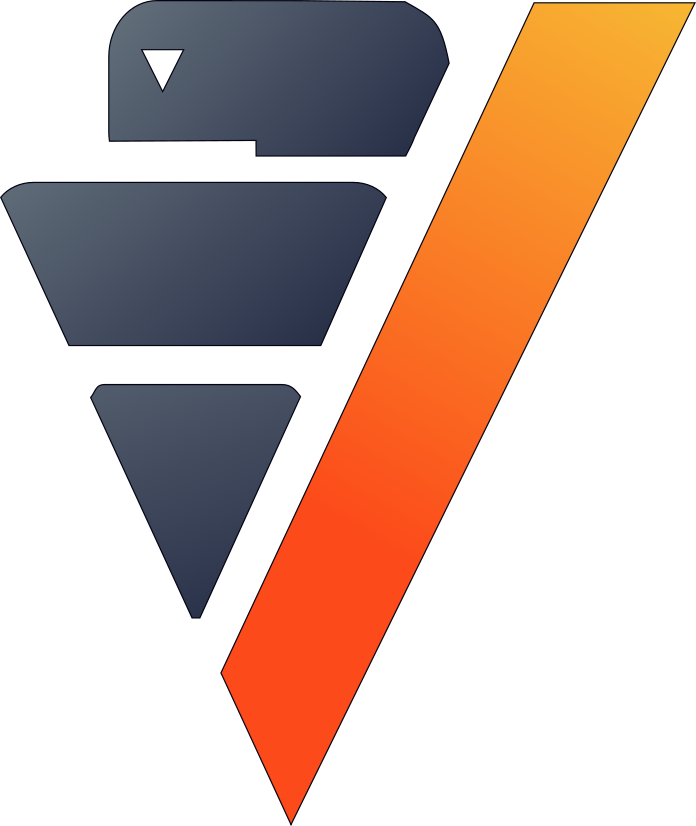

In [48]:
rf_model.regression_report()

,importance,sign
release_year,90.24,1
artist_popularity,5.21,1
instrumentalness,1.98,1
artists_followers,0.54,1
loudness,0.54,1
acousticness,0.31,1
energy,0.3,1
speechiness,0.24,1
duration_minute,0.21,1
nb_singers,0.13,1

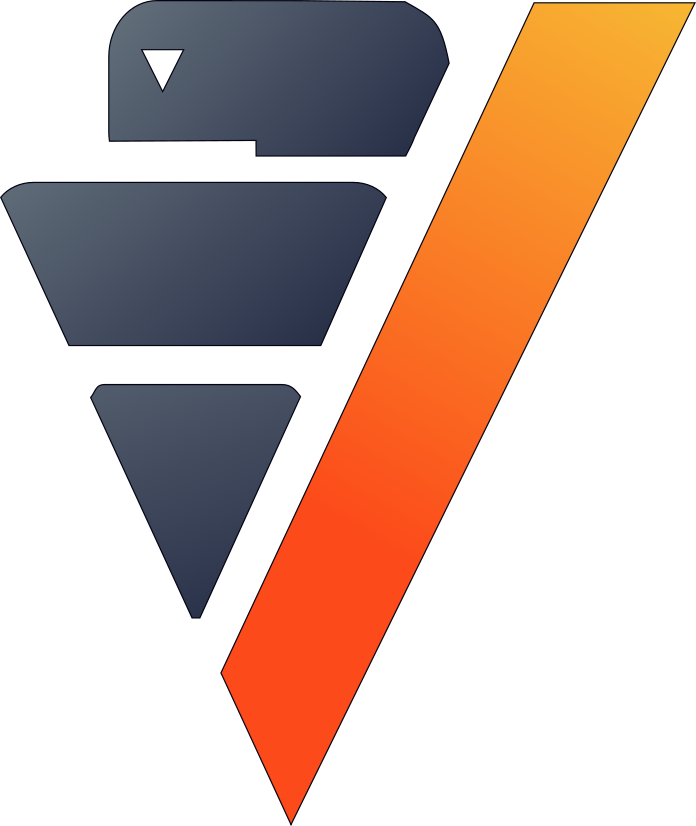

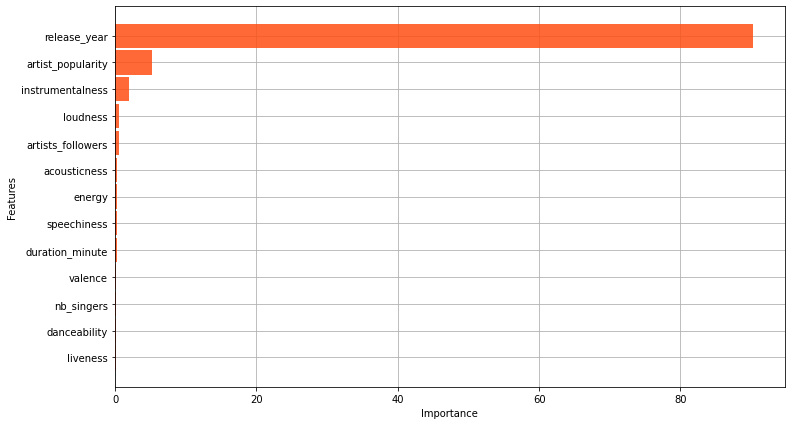

In [49]:
rf_model.features_importance()

To see how our model performs, let's plot the popularity and estimated popularity of songs by other Polish artists like Brodka, Akcent, and Maanam.

<AxesSubplot:xlabel='"name"'>

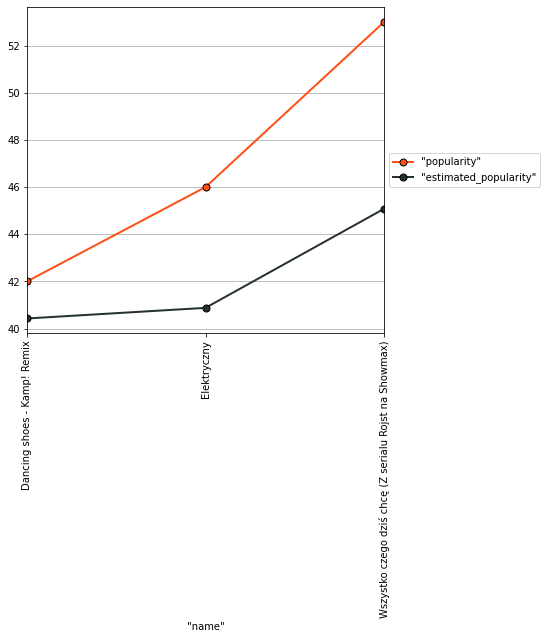

In [51]:
# results for Brodka
polish_tracks.search("LOWER(artists) LIKE '%brodka%'",
                     usecols = ['popularity', 'name', 'estimated_popularity']).plot(
                               ts='name', columns=['popularity', 'estimated_popularity'])

<AxesSubplot:xlabel='"name"'>

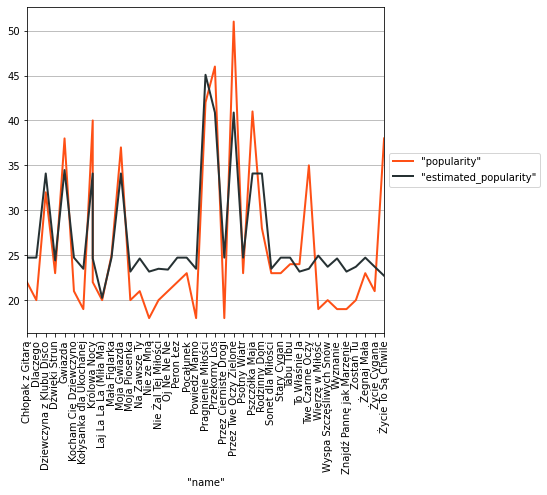

In [52]:
# results for Brodka
polish_tracks.search("LOWER(artists) LIKE '%akcent%'",
                     usecols = ['popularity', 'name', 'estimated_popularity']).plot(
                               ts='name', columns=['popularity', 'estimated_popularity'])

## Group Artists using Track Features

While our tracks don't have an explicit "genre" feature, we can approximate the effect by grouping artists based on their tracks' numerical features.

Let's start by taking the averages of these numerical features for each artist.

,AbcVarchar(156),AbcVarchar(100),123danceabilityFloat,123energyFloat,123speechinessFloat,123acousticnessFloat,123instrumentalnessFloat,123valenceFloat,123livenessFloat
1,,,0.667763157894737,0.779096504704241,0.309063080791516,0.111608040201005,0.000926305015353122,0.698505590970843,0.145271317829457
2,,,0.115131578947368,0.226837766464841,0.0139389963922595,0.978391959798995,0.0,0.0909708433483125,0.157105943152454
3,,,0.726973684210527,0.584801839523652,0.0137750081994095,0.199899497487437,0.0214651995905834,0.832270874699551,0.048372093023256
4,,,0.6875,0.661616009478768,0.076199846944353,0.108542713567839,1.97543500511771e-06,0.834883477897377,0.083100775193798
5,,,0.672149122807018,0.734915805645088,0.011588498961408,0.462311557788945,0.0,0.793081826732156,0.10077519379845
6,,,0.419557416267943,0.636878469303086,0.0352326147668883,0.465746916400183,0.00257370428956918,0.565262827881701,0.184947145877378
7,,,0.555921052631579,0.925696097036881,0.113370503990379,0.007336683417085,0.0,0.724109102309541,0.089405684754522
8,,,0.747807017543859,0.868964063017742,0.0984475784410185,0.164321608040201,0.000573183213920164,0.618559933117358,0.14687338501292
9,,,0.373903508771929,0.351347009267906,0.031212419372472,0.652763819095478,0.0,0.559515100846483,0.572093023255814
10,,,0.551535087719298,0.597353174483638,0.2850114791735,0.163819095477387,0.0,0.336398787752116,0.561757105943152

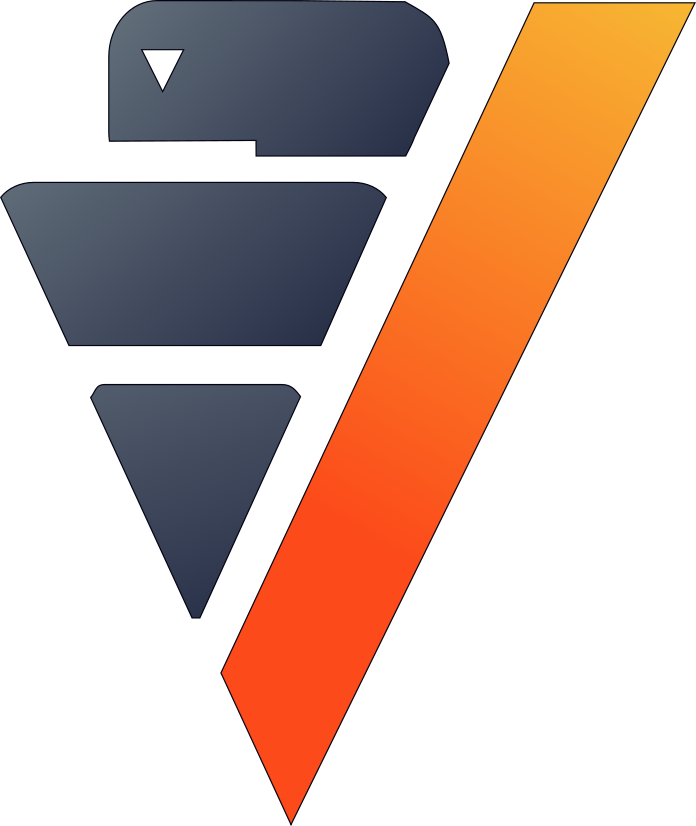

In [55]:
# group by artist
artists_features = polish_tracks.groupby(['id_artists',
                                          'artists'], expr=['AVG(danceability) AS danceability',
                                                            'AVG(energy) AS energy', 
                                                            'AVG(speechiness) AS speechiness', 
                                                            'AVG(acousticness) AS acousticness', 
                                                            'AVG(instrumentalness) AS instrumentalness',
                                                            'AVG(valence) AS valence', 
                                                            'AVG(liveness) AS liveness'])

# save relation to the database as "artists_features"
artists_features.to_db('"spotify"."artists_features"')

Grouping means clustering, so we use an elbow curve to find a suitable number of clusters.

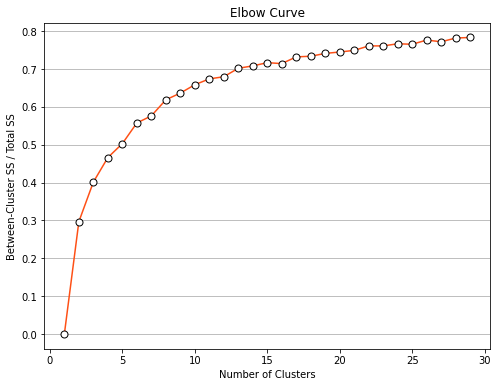

In [56]:
from verticapy.learn.model_selection import elbow

# define numerical features
preds = ["danceability",
         "energy",
         "speechiness",
         "acousticness",
         "instrumentalness",
         "liveness",
         "valence"]

# elbow curve
elbow = elbow('"spotify"."artists_features"',
              preds,
              n_cluster = (1, 30))

Let's define and use the Vertica k-means algorithm to create a model that can group artists together.

In [57]:
from verticapy.learn.cluster import KMeans

# define k-means
model = KMeans('"spotify"."KMeans_spotify"', 
               n_cluster = 7)

We can train our new model on the "artists_features" relation we saved earlier.

In [58]:
# train the model
model.fit('"spotify"."artists_features"', 
          X = preds)



centers
danceability| energy |speechiness|acousticness|instrumentalness|liveness|valence 
------------+--------+-----------+------------+----------------+--------+--------
   0.69555  | 0.78801|  0.10285  |   0.12729  |     0.01264    | 0.16900| 0.77472
   0.76995  | 0.64462|  0.27348  |   0.20702  |     0.00206    | 0.14808| 0.51245
   0.47486  | 0.36216|  0.03955  |   0.73322  |     0.01880    | 0.15942| 0.35397
   0.54658  | 0.69307|  0.06738  |   0.13429  |     0.09020    | 0.15264| 0.35517
   0.60919  | 0.75848|  0.17245  |   0.17270  |     0.06267    | 0.71443| 0.54388
   0.64666  | 0.63465|  0.15365  |   0.51753  |     0.01172    | 0.18339| 0.61588
   0.35545  | 0.24647|  0.02482  |   0.85935  |     0.78889    | 0.15544| 0.26981


metrics
Evaluation metrics:
     Total Sum of Squares: 236.02931
     Within-Cluster Sum of Squares: 
         Cluster 0: 19.761467
         Cluster 1: 12.785339
         Cluster 2: 12.796322
         Cluster 3: 23.034665
         Cluster 4: 5.882739

Plot the result of the k-means algoritm:

<AxesSubplot:xlabel='Dim1 (44.2%)', ylabel='Dim2 (18.6%)'>

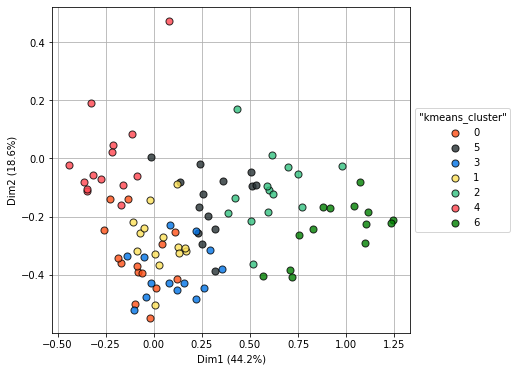

In [59]:
model.plot()

In [60]:
# predict the genres
pred_genres = model.predict('"spotify"."artists_features"', 
                            X = ["danceability",
                                 "energy",
                                 "speechiness",
                                 "acousticness",
                                 "instrumentalness",
                                 "liveness",
                                 "valence"], 
                            name="pred_genres")

Let's see how our model groups these artists together:

,AbcVarchar(100),123pred_genresInteger
1,,6
2,,6
3,,6
4,,6
5,,6
6,,6
7,,6
8,,6
9,,6
10,,6

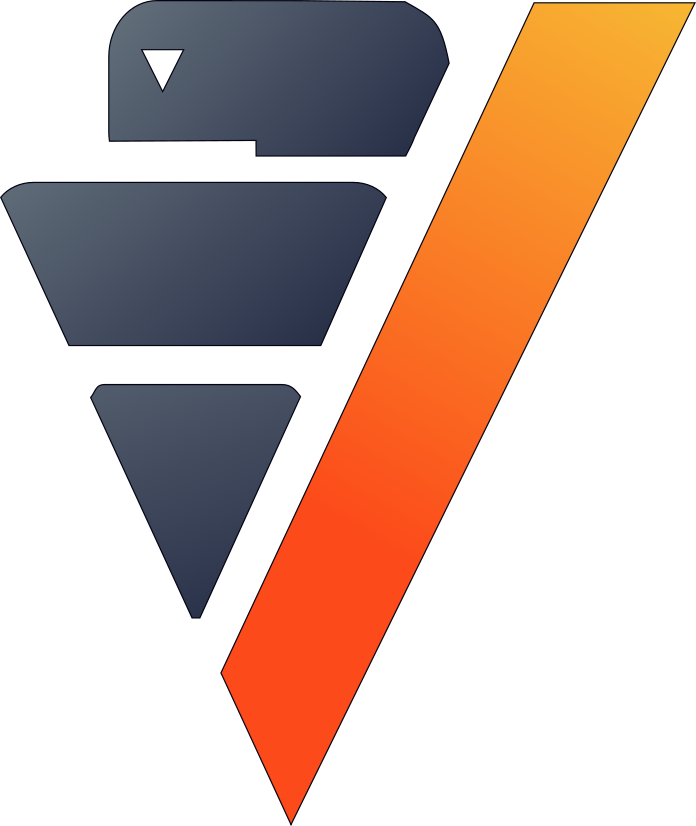

In [63]:
# observe the results
pred_genres['artists',
            'pred_genres'].sort({'pred_genres':'desc'})

## Conclusion

We were able to predict the popularity Polish songs with a RandomForestRegressor model suggested by AutoML. We then created a k-means model to group artists into "genres" (clusters) based on the feature-commonalities in their tracks.